In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             roc_auc_score
                             )
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Data collection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
credit = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/credit_record.csv')
app = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/application_record.csv')

# Visualizing and Analysing data

In [ ]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Number of people working status:
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


/tmp/ipykernel_863/1433533500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OCCUPATION_TYPE', data=app, palette = 'Set2')


<Axes: xlabel='OCCUPATION_TYPE', ylabel='count'>

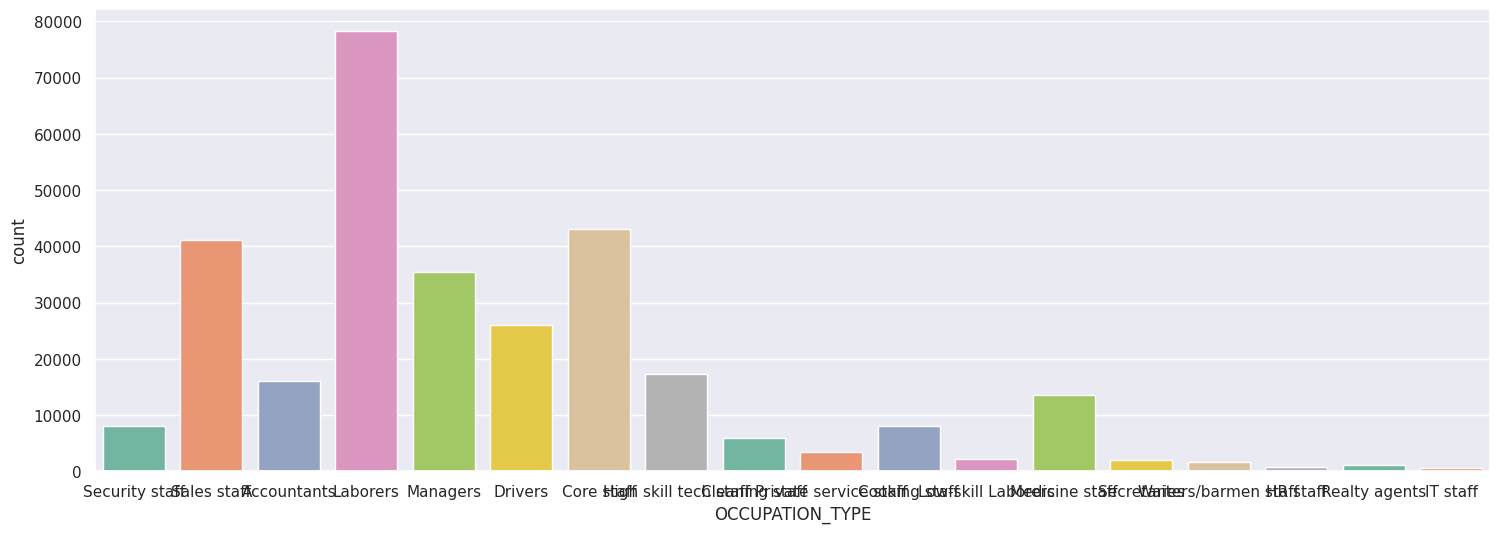

In [ ]:
print("Number of people working status:")
print(app['OCCUPATION_TYPE'].value_counts())
sns.set(rc = {'figure.figsize':(18,6)})
sns.countplot(x='OCCUPATION_TYPE', data=app, palette = 'Set2')

<Axes: >

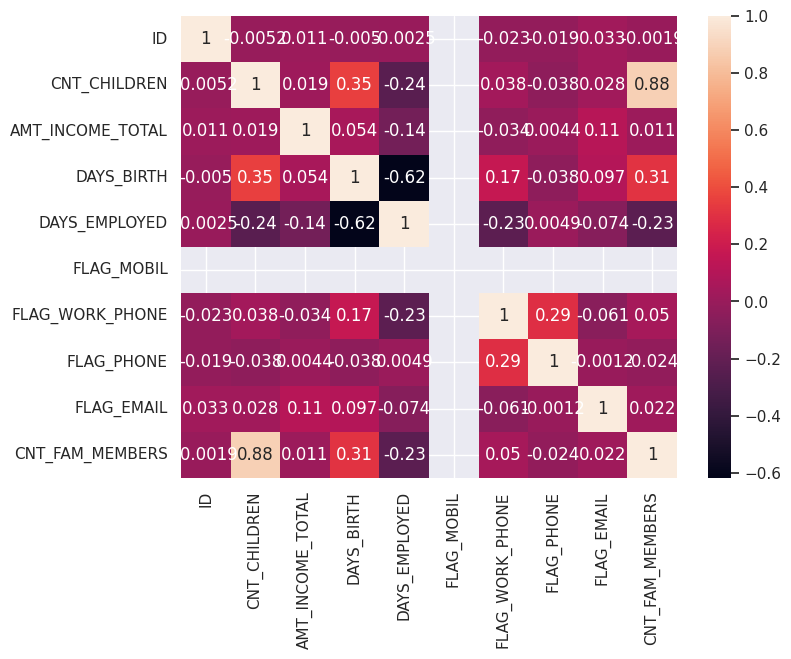

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(app.corr(numeric_only=True),annot=True)

In [ ]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


# Data preprocessing

**1)Duplicate records:-**
Removing duplicate records is an important preprocessing step in the Credit Card Approval Prediction project because each applicant should have a unique Applicant ID. Duplicate records may occur due to repeated data entry, merged files, or system errors, which can affect the accuracy and performance of the machine learning model.

In [ ]:
#dropping duplicate rows

app.drop_duplicates(subset = ['CODE_GENDER', 'FLAG_OWN_CAR',
                              'FLAG_OWN_REALTY', 'CNT_CHILDREN',
                              'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE',
                              'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
                              'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
                              'DAYS_EMPLOYED', 'FLAG_MOBIL',
                              'FLAG_WORK_PHONE', 'FLAG_PHONE',
                              'FLAG_EMAIL', 'OCCUPATION_TYPE',
                              'CNT_FAM_MEMBERS'],
                    keep = 'first', inplace = True)

In [ ]:
app.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90085 entries, 0 to 438553
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   90085 non-null  int64  
 1   CODE_GENDER          90085 non-null  object 
 2   FLAG_OWN_CAR         90085 non-null  object 
 3   FLAG_OWN_REALTY      90085 non-null  object 
 4   CNT_CHILDREN         90085 non-null  int64  
 5   AMT_INCOME_TOTAL     90085 non-null  float64
 6   NAME_INCOME_TYPE     90085 non-null  object 
 7   NAME_EDUCATION_TYPE  90085 non-null  object 
 8   NAME_FAMILY_STATUS   90085 non-null  object 
 9   NAME_HOUSING_TYPE    90085 non-null  object 
 10  DAYS_BIRTH           90085 non-null  int64  
 11  DAYS_EMPLOYED        90085 non-null  int64  
 12  FLAG_MOBIL           90085 non-null  int64  
 13  FLAG_WORK_PHONE      90085 non-null  int64  
 14  FLAG_PHONE           90085 non-null  int64  
 15  FLAG_EMAIL           90085 non-null  int

**2)Missing values:-**

In [ ]:
app.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
app.isnull().mean()

,0
ID,0.000000
CODE_GENDER,0.000000
FLAG_OWN_CAR,0.000000
FLAG_OWN_REALTY,0.000000
CNT_CHILDREN,0.000000
AMT_INCOME_TOTAL,0.000000
NAME_INCOME_TYPE,0.000000
NAME_EDUCATION_TYPE,0.000000
NAME_FAMILY_STATUS,0.000000
NAME_HOUSING_TYPE,0.000000


In this dataset, the occupation type column contains null values, but it is removed during the cleaning process because it is not required for final model training.

After checking the remaining columns, no missing values are found, so further imputation is not required. This process ensures that the dataset is clean, complete, and ready for preprocessing, feature selection, scaling, and machine learning model training.

**3)Data cleaning and merging:-**

In [ ]:

def data_cleaning(app, credit):
    # --- 1. CLEANING APPLICANT DATA ---

    # Create family_dependency: combine children and family members
    app['family_dependency'] = app['CNT_CHILDREN'] + app['CNT_FAM_MEMBERS']

    # Handle negative values for time-related features
    app['DAYS_BIRTH'] = abs(app['DAYS_BIRTH'])
    app['DAYS_EMPLOYED'] = abs(app['DAYS_EMPLOYED'])

    # Drop unnecessary columns (Example list)
    cols_to_drop = ['FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
    app.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    # Map categorical columns to numerical labels
    # Example mapping for Housing Type
    mapping_dict = {'House / apartment': 0, 'With parents': 1, 'Municipal apartment': 2,
                    'Rented apartment': 3, 'Office apartment': 4, 'Co-op apartment': 5}
    app['NAME_HOUSING_TYPE'] = app['NAME_HOUSING_TYPE'].map(mapping_dict)

    # --- 2. CLEANING AND MERGING CREDIT DATA ---

    # Group by ID to handle multiple records
    # Create new features based on credit history period
    credit['open_month'] = credit.groupby('ID')['MONTHS_BALANCE'].transform('min')
    credit['end_months'] = credit.groupby('ID')['MONTHS_BALANCE'].transform('max')
    credit['window'] = credit['end_months'] - credit['open_month']

    # Interpret STATUS (Example logic: 0-5 are overdue, C/X are good/no records)
    status_map = {'C': 0, 'X': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6}
    credit['STATUS'] = credit['STATUS'].map(status_map)

    # Aggregate credit data by ID before merging with applicant data
    credit_agg = credit.groupby('ID').agg({
        'STATUS': 'max',
        'window': 'first'
    }).reset_index()

    # --- 3. MERGE ---
    final_df = pd.merge(app, credit_agg, on='ID', how='inner')

    return final_df

# Usage:
# cleaned_data = data_cleaning(application_record, credit_record)

In [ ]:
final_df = data_cleaning(app,credit)

In [ ]:
final_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,family_dependency,STATUS,window
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,3,12005,4542,NaN,2.0,2.0,2,15
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,0,21474,1134,Security staff,2.0,2.0,1,29
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,0,19110,3051,Sales staff,1.0,1.0,1,4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,0,22464,365243,NaN,1.0,1.0,1,16
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,0,16872,769,Accountants,2.0,2.0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,2,20600,198,Laborers,2.0,2.0,3,20
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,0,15837,2694,NaN,2.0,2.0,3,19
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,0,19101,1721,NaN,2.0,2.0,3,21
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,0,12387,1325,Medicine staff,2.0,2.0,6,32


The **data_cleaning()** function is used to clean, transform, and prepare the applicant dataset before machine learning model training. Raw datasets may contain unnecessary columns, negative values, inconsistent information, and categorical features that must be converted into a useful format for analysis and prediction.

In this process, a new column is created by combining family members and children information to better represent family dependency. Unnecessary columns are removed to reduce complexity and improve model performance. The **DAYS_BIRTH** and **DAYS_EMPLOYED** columns contain negative values, so the abs() function is used to convert them into positive values for easier interpretation and analysis.

Feature mapping is applied to categorical columns such as housing type, income type, education type, and family type to convert text values into numerical labels suitable for machine learning algorithms. For the credit records dataset, the data is grouped using the ID column to combine multiple monthly records for each applicant. New features such as **open_month, end_months, and window** are created from the MONTHS_BALANCE column to represent the applicant’s credit activity period. The STATUS column is also interpreted to identify payment behavior such as timely payments, overdue payments, and no loan records, which helps improve credit approval prediction accuracy.

**4)Feature Engineering:-**

In [ ]:
final_df['STATUS_BIN'] = (final_df['STATUS'] > 1).astype(int)

In [ ]:
final_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,family_dependency,STATUS,window,STATUS_BIN
0,5008804,1,1,1,0,427500.0,4,1,0,3,12005,4542,2.0,2.0,2,15,1
1,5008806,1,1,1,0,112500.0,4,4,1,0,21474,1134,2.0,2.0,1,29,0
2,5008808,0,0,1,0,270000.0,0,4,3,0,19110,3051,1.0,1.0,1,4,0
3,5008812,0,0,1,0,283500.0,1,1,2,0,22464,365243,1.0,1.0,1,16,0
4,5008815,1,1,1,0,270000.0,4,1,1,0,16872,769,2.0,2.0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,1,4,0,2,20600,198,2.0,2.0,3,20,1
9705,5149055,0,0,1,0,112500.0,0,4,1,0,15837,2694,2.0,2.0,3,19,1
9706,5149729,1,1,1,0,90000.0,4,4,1,0,19101,1721,2.0,2.0,3,21,1
9707,5149838,0,0,1,0,157500.0,1,1,1,0,12387,1325,2.0,2.0,6,32,1


In [ ]:
print("\nMissing values in each column:")
print(final_df.isnull().sum().sort_values(ascending=False))


Missing values in each column:
ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
CNT_FAM_MEMBERS        0
family_dependency      0
STATUS                 0
window                 0
STATUS_BIN             0
dtype: int64


**5)Handling categorical values:-**

In [ ]:
from sklearn.preprocessing import LabelEncoder

cg = LabelEncoder()
oc = LabelEncoder()
own_r = LabelEncoder()
it = LabelEncoder()
et = LabelEncoder()
fs = LabelEncoder()
ht = LabelEncoder()


final_df['CODE_GENDER'] = cg.fit_transform(final_df['CODE_GENDER'])
final_df['FLAG_OWN_CAR'] = oc.fit_transform(final_df['FLAG_OWN_CAR'])
final_df['FLAG_OWN_REALTY'] = own_r.fit_transform(final_df['FLAG_OWN_REALTY'])
final_df['NAME_INCOME_TYPE'] = it.fit_transform(final_df['NAME_INCOME_TYPE'])
final_df['NAME_EDUCATION_TYPE'] = et.fit_transform(final_df['NAME_EDUCATION_TYPE'])
final_df['NAME_FAMILY_STATUS'] = fs.fit_transform(final_df['NAME_FAMILY_STATUS'])
final_df['NAME_HOUSING_TYPE'] = ht.fit_transform(final_df['NAME_HOUSING_TYPE'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Gender
le = LabelEncoder()
le.fit(app['CODE_GENDER'])
print("CODE_GENDER:", dict(zip(le.classes_, le.transform(le.classes_))))

# Own Car
le = LabelEncoder()
le.fit(app['FLAG_OWN_CAR'])
print("FLAG_OWN_CAR:", dict(zip(le.classes_, le.transform(le.classes_))))

# Own Realty
le = LabelEncoder()
le.fit(app['FLAG_OWN_REALTY'])
print("FLAG_OWN_REALTY:", dict(zip(le.classes_, le.transform(le.classes_))))

# Income Type
le = LabelEncoder()
le.fit(app['NAME_INCOME_TYPE'])
print("NAME_INCOME_TYPE:", dict(zip(le.classes_, le.transform(le.classes_))))

# Education
le = LabelEncoder()
le.fit(app['NAME_EDUCATION_TYPE'])
print("NAME_EDUCATION_TYPE:", dict(zip(le.classes_, le.transform(le.classes_))))

# Family Status
le = LabelEncoder()
le.fit(app['NAME_FAMILY_STATUS'])
print("NAME_FAMILY_STATUS:", dict(zip(le.classes_, le.transform(le.classes_))))

# Housing Type
le = LabelEncoder()
le.fit(app['NAME_HOUSING_TYPE'])
print("NAME_HOUSING_TYPE:", dict(zip(le.classes_, le.transform(le.classes_))))

CODE_GENDER: {'F': np.int64(0), 'M': np.int64(1)}
FLAG_OWN_CAR: {'N': np.int64(0), 'Y': np.int64(1)}
FLAG_OWN_REALTY: {'N': np.int64(0), 'Y': np.int64(1)}
NAME_INCOME_TYPE: {'Commercial associate': np.int64(0), 'Pensioner': np.int64(1), 'State servant': np.int64(2), 'Student': np.int64(3), 'Working': np.int64(4)}
NAME_EDUCATION_TYPE: {'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Incomplete higher': np.int64(2), 'Lower secondary': np.int64(3), 'Secondary / secondary special': np.int64(4)}
NAME_FAMILY_STATUS: {'Civil marriage': np.int64(0), 'Married': np.int64(1), 'Separated': np.int64(2), 'Single / not married': np.int64(3), 'Widow': np.int64(4)}
NAME_HOUSING_TYPE: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}


In [ ]:
final_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,family_dependency,STATUS,window,STATUS_BIN
0,5008804,1,1,1,0,427500.0,4,1,0,3,12005,4542,2.0,2.0,2,15,1
1,5008806,1,1,1,0,112500.0,4,4,1,0,21474,1134,2.0,2.0,1,29,0
2,5008808,0,0,1,0,270000.0,0,4,3,0,19110,3051,1.0,1.0,1,4,0
3,5008812,0,0,1,0,283500.0,1,1,2,0,22464,365243,1.0,1.0,1,16,0
4,5008815,1,1,1,0,270000.0,4,1,1,0,16872,769,2.0,2.0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,1,4,0,2,20600,198,2.0,2.0,3,20,1
9705,5149055,0,0,1,0,112500.0,0,4,1,0,15837,2694,2.0,2.0,3,19,1
9706,5149729,1,1,1,0,90000.0,4,4,1,0,19101,1721,2.0,2.0,3,21,1
9707,5149838,0,0,1,0,157500.0,1,1,1,0,12387,1325,2.0,2.0,6,32,1


# Model Building

**1)Logistic Regression Model:-**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def logistic_reg(X_train, X_test, y_train, y_test):
    """
    Builds, trains, tests, and evaluates a Logistic Regression classification model.
    Accepts pre-split training and testing data (X_train, X_test, y_train, y_test).
    Returns the trained model and its predictions.
    """

    # --- MODEL INITIALIZATION ---
    print("Initializing Logistic Regression classifier...")
    # Initialize Logistic Regression with a fixed random state for reproducibility
    lr_model = LogisticRegression(random_state=42, max_iter=1000)

    # --- MODEL TRAINING ---
    print("Training the Logistic Regression model on training data...")
    # X_train contains input features (Income, education, credit history, etc.)
    # y_train contains target labels (approval status: 1=Approved, 0=Not Approved)
    lr_model.fit(X_train, y_train)

    # --- MODEL PREDICTION ---
    print("Generating predictions on the unseen test dataset...")
    # Predicts approval status for new applicants in X_test
    y_pred = lr_model.predict(X_test)

    # --- MODEL EVALUATION ---
    print("\n- Model Evaluation Results")

    # 1. Confusion Matrix: Shows counts of True Positives, True Negatives, False Positives, and False Negatives.
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # 2. Classification Report: Generates precision, recall, f1-score, and support metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # --- OPTIONAL VISUAL REPRESENTATION (Seaborn Heatmap) ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Logistic Regression')
    plt.show()

    return lr_model, y_pred


**2)Random Forest Model:-**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

def random_forest(X_train, X_test, y_train, y_test):
    """
    Builds, trains, and tests a Random Forest classification model,
    returning performance metrics.
    """

    # RandomForestClassifier() is initialized.
    # We use some common default hyperparameters for good initial performance.
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    # Trained on the training data.
    print("\nTraining Random Forest model...")
    rf_model.fit(X_train, y_train)

    # Tested on the test set.
    print("Generating predictions...")
    y_pred = rf_model.predict(X_test)

    # Performance is assessed using the confusion matrix and classification report.
    print("\n" + "="*40)
    print("Random Forest Model Evaluation")
    print("="*40)

    # Classification Report provides Precision, Recall, F1-score, and Support for each class.
    print("\n*** Classification Report ***")
    print(classification_report(y_test, y_pred))


**3)Decision Tree Model:-**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

def d_tree(xtrain, xtest, ytrain, ytest):
    # Initialize the model with an equals sign (=) instead of a hyphen (-)
    dt = DecisionTreeClassifier()

    # Train the model
    dt.fit(xtrain, ytrain)

    # Assign predictions using an equals sign (=)
    ypred = dt.predict(xtest)

    # Fix matching quotes for all print statements
    print('***DecisionTreeClassifier***')
    print('Confusion matrix')
    print(confusion_matrix(ytest, ypred))
    print('Classification report')
    print(classification_report(ytest, ypred))


In [ ]:
X = final_df.drop(columns=['ID','STATUS','STATUS_BIN'])

# Target
y = final_df['STATUS_BIN']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X.columns.tolist())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'family_dependency', 'window']


In [ ]:
print(y.value_counts())

STATUS_BIN
0    8426
1    1283
Name: count, dtype: int64


Initializing Logistic Regression classifier...
Training the Logistic Regression model on training data...
Generating predictions on the unseen test dataset...

- Model Evaluation Results
Confusion Matrix:
[[1685    0]
 [ 257    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1685
           1       0.00      0.00      0.00       257

    accuracy                           0.87      1942
   macro avg       0.43      0.50      0.46      1942
weighted avg       0.75      0.87      0.81      1942



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

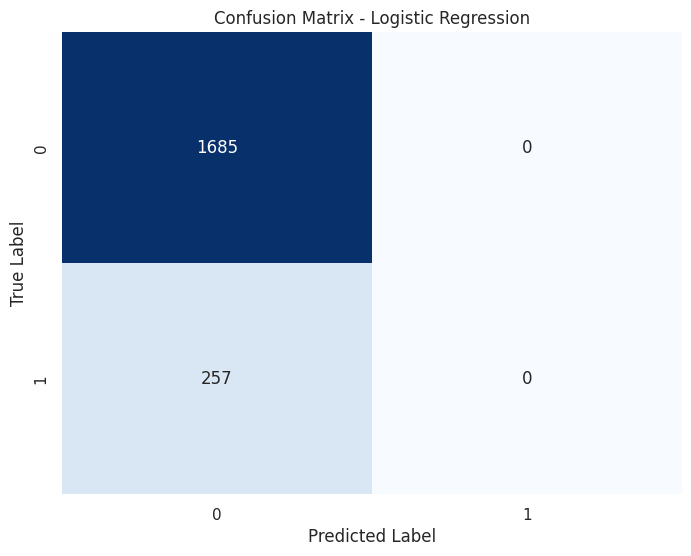

In [ ]:
lr_model, lr_pred = logistic_reg(X_train, X_test, y_train, y_test)

In [ ]:
random_forest(X_train, X_test, y_train, y_test)


Training Random Forest model...
Generating predictions...

Random Forest Model Evaluation

*** Classification Report ***
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1685
           1       0.33      0.01      0.02       257

    accuracy                           0.87      1942
   macro avg       0.60      0.50      0.47      1942
weighted avg       0.80      0.87      0.81      1942



In [ ]:
d_tree(X_train, X_test, y_train, y_test)

***DecisionTreeClassifier***
Confusion matrix
[[1444  241]
 [ 224   33]]
Classification report
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1685
           1       0.12      0.13      0.12       257

    accuracy                           0.76      1942
   macro avg       0.49      0.49      0.49      1942
weighted avg       0.77      0.76      0.76      1942



In [ ]:
import joblib

joblib.dump(lr_model, "credit_card_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
